In [1]:
# Step 1: Import Necessary Libraries
print("Step 1: Importing libraries...")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
import lightgbm as lgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import os
import joblib
from wordcloud import WordCloud
import time

# Set plot style for better visualizations
sns.set_style('whitegrid')
print("Libraries imported successfully.\n")


Step 1: Importing libraries...
Libraries imported successfully.



In [2]:
# Step 2: Mount Google Drive and Load Preprocessed Data
print("Step 2: Loading preprocessed data from Google Drive...")
try:
    if not os.path.isdir('/content/drive/My Drive'):
        drive.mount('/content/drive')

    # --- IMPORTANT ---
    # Please update this path to the location of your preprocessed CSV file in your Google Drive.
    file_path = '/content/drive/MyDrive/AIML assignment/results/preprocessed_reviews.csv'

    if not os.path.exists(file_path):
        raise FileNotFoundError(f"The file was not found at '{file_path}'. Please double-check the path.")

    df = pd.read_csv(file_path)
    df.dropna(subset=['review', 'sentiment'], inplace=True)

    print("Preprocessed dataset loaded successfully.")
    print("\nDataset Head:")
    print(df.head())
except Exception as e:
    print(f"An error occurred: {e}")


Step 2: Loading preprocessed data from Google Drive...
Mounted at /content/drive
Preprocessed dataset loaded successfully.

Dataset Head:
                                              review  sentiment
0  one review mention watch oz episod hook right ...          1
1  wonder littl product film techniqu unassum old...          1
2  thought wonder way spend time hot summer weeke...          1
3  basic famili littl boy jake think zombi closet...          0
4  petter mattei love time money visual stun film...          1



Step 3: Performing Exploratory Data Analysis (EDA)...


/tmp/ipython-input-3159846632.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df, palette='viridis')


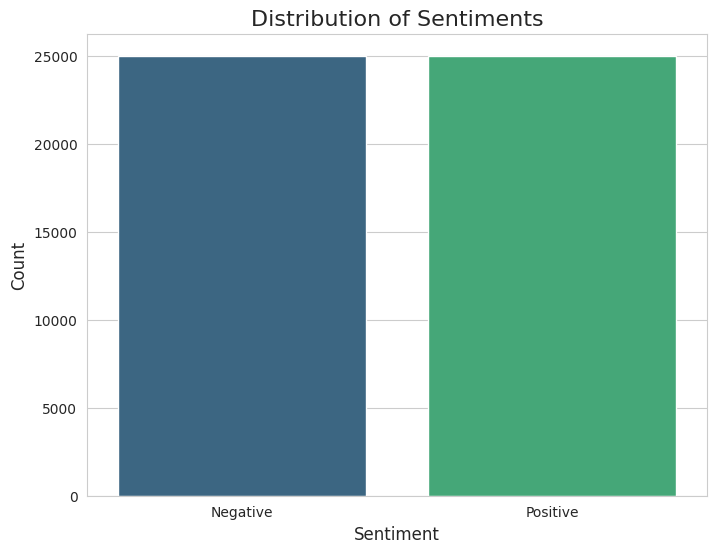


Generating Word Cloud...


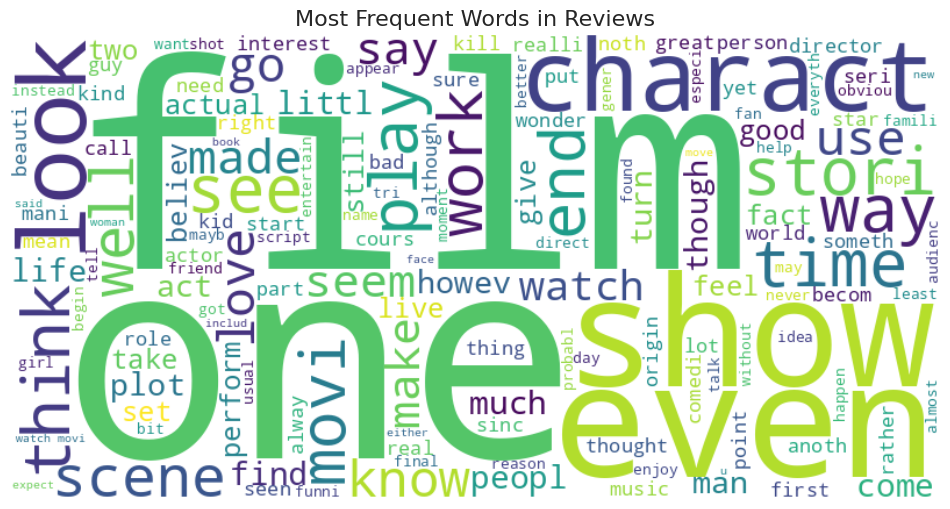

In [3]:
# Step 3: Exploratory Data Analysis (EDA)
print("\nStep 3: Performing Exploratory Data Analysis (EDA)...")

# EDA 1: Sentiment Distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='sentiment', data=df, palette='viridis')
plt.title('Distribution of Sentiments', fontsize=16)
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks([0, 1], ['Negative', 'Positive'])
plt.show()

# EDA 2: Word Cloud
print("\nGenerating Word Cloud...")
all_reviews = ' '.join(df['review'])
wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=150).generate(all_reviews)
plt.figure(figsize=(12, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words in Reviews', fontsize=16)
plt.show()

In [4]:
# Step 4: Feature Extraction and Data Splitting
print("\nStep 4: Performing TF-IDF Vectorization and splitting data...")
df['review'].fillna('', inplace=True)
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X = vectorizer.fit_transform(df['review'])
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples\n")



Step 4: Performing TF-IDF Vectorization and splitting data...


/tmp/ipython-input-3229788170.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['review'].fillna('', inplace=True)


Training set size: 40000 samples
Testing set size: 10000 samples



Step 5: Training and evaluating a baseline LightGBM model (before tuning)...
[LightGBM] [Info] Number of positive: 20000, number of negative: 20000
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 2.574112 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 625598
[LightGBM] [Info] Number of data points in the train set: 40000, number of used features: 5000
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Baseline Model Accuracy: 0.8627 (86.27%)

Baseline Model Confusion Matrix:


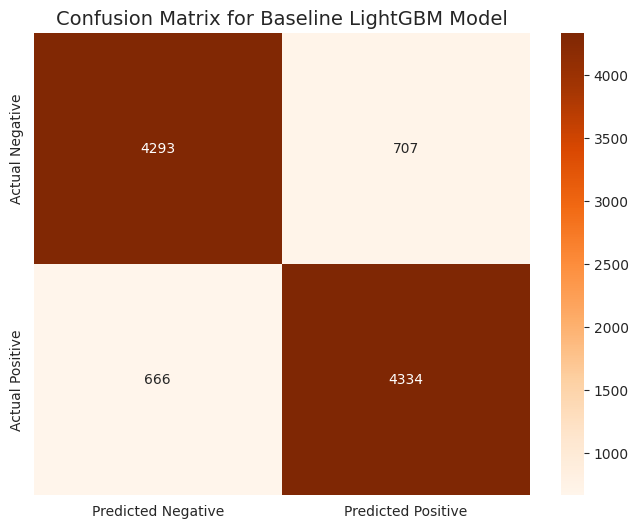

In [5]:
# Step 5: Baseline Model (Before Hyperparameter Tuning)
print("Step 5: Training and evaluating a baseline LightGBM model (before tuning)...")
baseline_model = lgb.LGBMClassifier(random_state=42)
baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test)
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
print(f"\nBaseline Model Accuracy: {baseline_accuracy:.4f} ({baseline_accuracy:.2%})")

print("\nBaseline Model Confusion Matrix:")
cm_baseline = confusion_matrix(y_test, y_pred_baseline)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.title('Confusion Matrix for Baseline LightGBM Model', fontsize=14)
plt.show()

In [6]:
# Step 6: Hyperparameter Tuning with GridSearchCV
print("\nStep 6: Performing hyperparameter tuning with GridSearchCV...")
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'num_leaves': [31, 50]
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    estimator=lgb.LGBMClassifier(random_state=42),
    param_grid=param_grid, cv=cv, n_jobs=-1, verbose=2, scoring='accuracy'
)
start_time = time.time()
grid_search.fit(X_train, y_train)
end_time = time.time()
print(f"\nGridSearchCV completed in {end_time - start_time:.2f} seconds.")
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

print("\n--- Hyperparameter Tuning Results ---")
cv_results_df = pd.DataFrame(grid_search.cv_results_)
for i, params in enumerate(cv_results_df['params']):
    print(f"\nTuning {i+1}: {params}")
    print(f"Mean CV Accuracy: {cv_results_df['mean_test_score'][i]:.4f}")



Step 6: Performing hyperparameter tuning with GridSearchCV...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
[LightGBM] [Info] Number of positive: 20000, number of negative: 20000
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 2.115166 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 625598
[LightGBM] [Info] Number of data points in the train set: 40000, number of used features: 5000
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000

GridSearchCV completed in 2782.90 seconds.
Best parameters found: {'learning_rate': 0.1, 'n_estimators': 200, 'num_leaves': 50}
Best cross-validation accuracy: 0.8784

--- Hyperparameter Tuning Results ---

Tuning 1: {'learning_rate': 0.05, 'n_estimators': 100, 'num_leaves': 31}
Mean CV Accuracy: 0.8369

Tuning 2: {'learning_rate': 0.05, 'n_estimators': 100, 'num_leaves': 50}
Mean CV Accuracy: 0.8440

Tuning 3: {'learning_rate': 


Step 7: Evaluating the final tuned model...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Final Tuned Model Accuracy: 0.8795 (87.95%)

Final Model Classification Report:
              precision    recall  f1-score   support

    Negative       0.88      0.88      0.88      5000
    Positive       0.88      0.88      0.88      5000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000


Final Model Confusion Matrix:


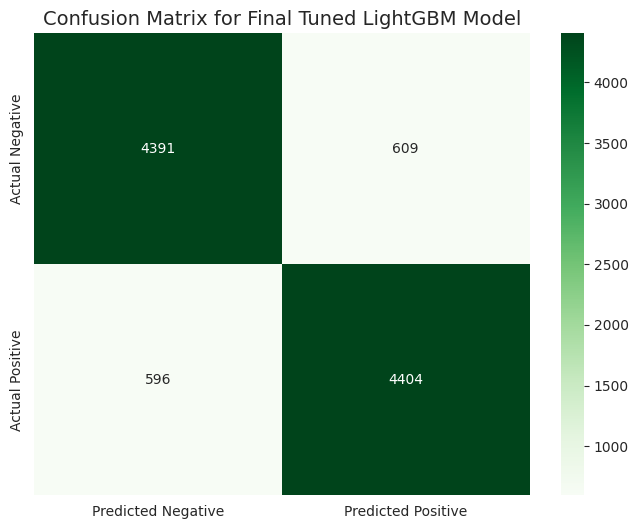

In [7]:
# Step 7: Final Model Evaluation (After Tuning)
print("\nStep 7: Evaluating the final tuned model...")
best_model = grid_search.best_estimator_
y_pred_final = best_model.predict(X_test)
final_accuracy = accuracy_score(y_test, y_pred_final)
print(f"\nFinal Tuned Model Accuracy: {final_accuracy:.4f} ({final_accuracy:.2%})")

print("\nFinal Model Classification Report:")
print(classification_report(y_test, y_pred_final, target_names=['Negative', 'Positive']))

print("\nFinal Model Confusion Matrix:")
cm_final = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.title('Confusion Matrix for Final Tuned LightGBM Model', fontsize=14)
plt.show()


Step 8: Visualizing comparison of model performances...


/tmp/ipython-input-1992784273.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=comparison_df, palette='coolwarm')


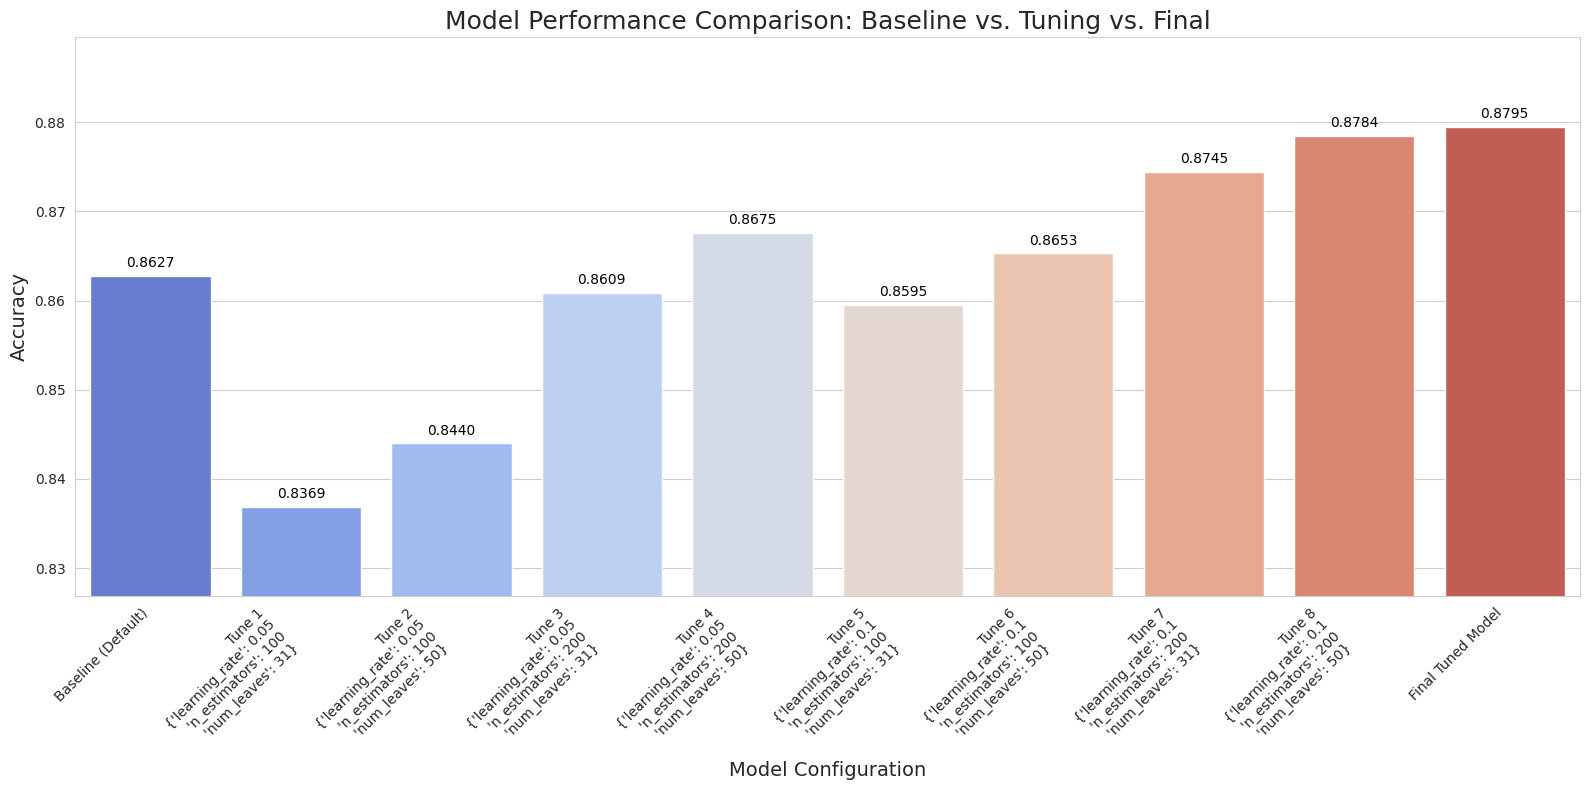

In [8]:
# Step 8: Comparative Visualization
print("\nStep 8: Visualizing comparison of model performances...")

# Data for the plot
model_names = [f"Tune {i+1}\n{str(p).replace(', ', '\n')}" for i, p in enumerate(cv_results_df['params'])]
accuracies = cv_results_df['mean_test_score']

# Add baseline and final accuracies
comparison_data = {
    'Model': ['Baseline (Default)'] + model_names + ['Final Tuned Model'],
    'Accuracy': [baseline_accuracy] + list(accuracies) + [final_accuracy]
}
comparison_df = pd.DataFrame(comparison_data)

plt.figure(figsize=(16, 8))
sns.barplot(x='Model', y='Accuracy', data=comparison_df, palette='coolwarm')
plt.title('Model Performance Comparison: Baseline vs. Tuning vs. Final', fontsize=18)
plt.ylabel('Accuracy', fontsize=14)
plt.xlabel('Model Configuration', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.ylim(min(comparison_df['Accuracy']) - 0.01, max(comparison_df['Accuracy']) + 0.01)
for index, row in comparison_df.iterrows():
    plt.text(index, row.Accuracy + 0.001, f'{row.Accuracy:.4f}', color='black', ha="center")
plt.tight_layout()
plt.show()


In [9]:
# Step 9: Save the Model and Results
print("\nStep 9: Saving the model, vectorizer, and results...")
results_dir = '/content/drive/MyDrive/AIML assignment/results/lightgbm_results'
os.makedirs(results_dir, exist_ok=True)

# Save model and vectorizer
joblib.dump(best_model, os.path.join(results_dir, 'lightgbm_model.pkl'))
joblib.dump(vectorizer, os.path.join(results_dir, 'tfidf_vectorizer.pkl'))

# Save reports
report_df = pd.DataFrame(classification_report(y_test, y_pred_final, output_dict=True)).transpose()
report_df.to_csv(os.path.join(results_dir, 'classification_report.csv'))
comparison_df.to_csv(os.path.join(results_dir, 'performance_comparison.csv'))

with open(os.path.join(results_dir, 'accuracy.txt'), 'w') as f:
    f.write(f'Baseline Model Accuracy: {baseline_accuracy:.4f}\n')
    f.write(f'Final Tuned Model Accuracy: {final_accuracy:.4f}\n')

print(f"\nAll results, model, and vectorizer have been saved to {results_dir}")


Step 9: Saving the model, vectorizer, and results...

All results, model, and vectorizer have been saved to /content/drive/MyDrive/AIML assignment/results/lightgbm_results
